# Capacity Utilization & Load Factor Analysis
This notebook explores aircraft utilization and passenger load factors across routes and seasons.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
processed_dir = os.path.join(base_dir, 'data', 'processed')
figures_dir = os.path.join(base_dir, 'reports', 'figures')

df_flights = pd.read_pickle(os.path.join(processed_dir, 'flights_clean.pkl'))
df_bookings = pd.read_pickle(os.path.join(processed_dir, 'bookings_clean.pkl'))

### Compute Load Factors

In [3]:
pax_count = df_bookings.groupby('FlightID').size().reset_index(name='PassengerCount')
df_util = df_flights.merge(pax_count, on='FlightID', how='left').fillna(0)
df_util['LoadFactor'] = df_util['PassengerCount'] / df_util['TotalCapacity']
df_util['RouteName'] = df_util['OriginAirport'] + ' - ' + df_util['DestAirport']

# Route Level Load Factor
route_util = df_util.groupby('RouteName').agg(
    AvgLoadFactor=('LoadFactor', 'mean'),
    TotalFlights=('FlightID', 'count')
).reset_index().sort_values('AvgLoadFactor', ascending=False)
route_util.head()

,RouteName,AvgLoadFactor,TotalFlights
0,ATL - MIA,0.825881,494
5,JFK - LAX,0.825856,516
3,DFW - DEN,0.825813,504
2,DEN - DFW,0.825599,510
6,LAX - JFK,0.824339,522


### Seasonality Analysis

In [4]:
df_util['DepartureDateTime'] = pd.to_datetime(df_util['DepartureDateTime'])
df_util['Month'] = df_util['DepartureDateTime'].dt.month

monthly_util = df_util.groupby('Month').agg(
    AvgLoadFactor=('LoadFactor', 'mean')
).reset_index()

### Visualizations

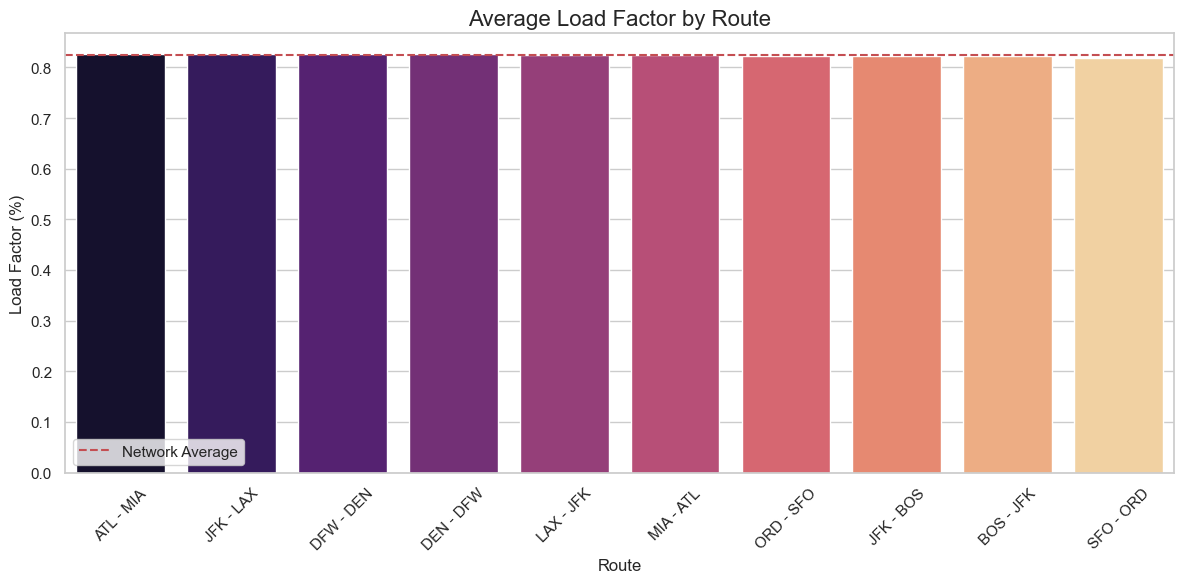

In [5]:
# Plot 1: Load Factor by Route
plt.figure(figsize=(12, 6))
sns.barplot(data=route_util, x='RouteName', y='AvgLoadFactor', palette='magma')
plt.title('Average Load Factor by Route', fontsize=16)
plt.ylabel('Load Factor (%)', fontsize=12)
plt.xlabel('Route', fontsize=12)
plt.axhline(y=df_util['LoadFactor'].mean(), color='r', linestyle='--', label='Network Average')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'load_factor_by_route.png'))
plt.show()

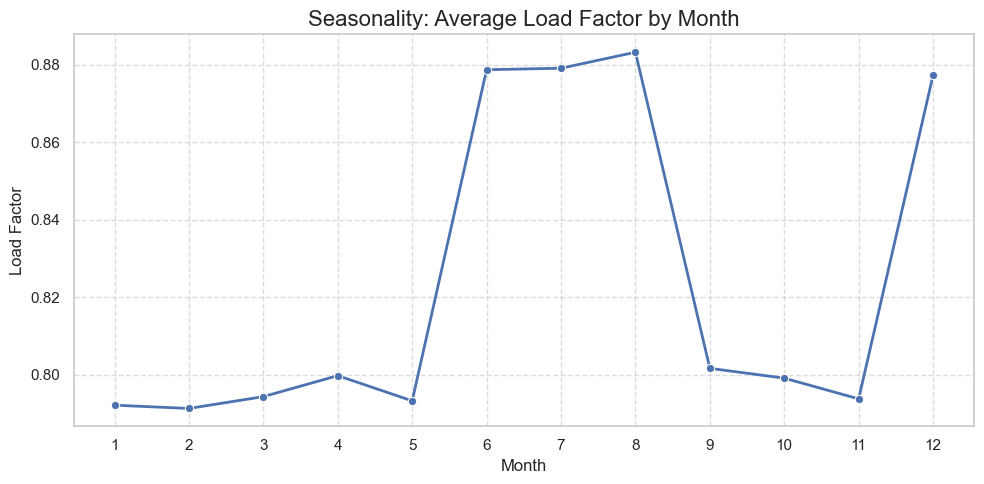

Capacity utilization analysis complete and figures saved.


In [6]:
# Plot 2: Seasonality of Load Factors
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_util, x='Month', y='AvgLoadFactor', marker='o', color='b', linewidth=2)
plt.title('Seasonality: Average Load Factor by Month', fontsize=16)
plt.ylabel('Load Factor', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'load_factor_seasonality.png'))
plt.show()

print("Capacity utilization analysis complete and figures saved.")